In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

from matplotlib import patches

torch.manual_seed(67)

In [2]:
class NN(torch.nn.Module):
    def __init__(self, input_dim, output_dim, layers, neurons, activation = 'tanh'):
        super(NN, self).__init__()
        self.activation = activation

        self.input_layer   = torch.nn.Linear(input_dim, neurons, bias = True)
        self.hidden_layers = torch.nn.ModuleList([torch.nn.Linear(neurons, neurons, bias = True) for _ in range(layers)])
        self.output_layer  = torch.nn.Linear(neurons, output_dim, bias = True)
        
        if self.activation == 'tanh':
            self.act = nn.Tanh()
        elif self.activation == 'relu':
            self.act = nn.ReLU()
        elif self.activation == 'gelu':
            self.act = nn.GELU()
        elif self.activation == 'sin':
            self.act = torch.sin  
        else:
            raise ValueError(f"Unknown activation: {activation}")
    
    def forward(self, x):
        a =  self.input_layer(x)
        for l in self.hidden_layers:
            a = self.act(l(a))
        return self.output_layer(a)
    
    
    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                if self.activation == 'sin':
                    nn.init.xavier_uniform_(m.weight)
                else:
                    g = nn.init.calculate_gain(self.activation)
                    torch.nn.init.xavier_uniform_(m.weight, gain=g)
                m.bias.data.fill_(0)
        self.apply(init_weights)

sum(p.numel() for p in NN(5, 5, 5, 5).parameters())

210

In [3]:
BATCH_SIZE = 32
EPOCHS  = 50

In [4]:
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

class dataset(torch.utils.data.Dataset):
    def __init__(self, engine: torch.quasirandom.SobolEngine, draw: int):
        self.data = engine.draw(draw) 

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
train_dataset_obj = dataset(sobol_engine, 1000)
train_dataloader = torch.utils.data.DataLoader(train_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

test_dataset_obj = dataset(sobol_engine, 500)
test_dataloader = torch.utils.data.DataLoader(test_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
def f(x):
    return torch.sin(x)

def g(t):
    return torch.sin(t)

domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]

def get_initial(data, f):
    data = data.clone()
    data[:,0] = domain[0][0] + (domain[0][1] - domain[0][0]) * data[:,0]

    data[:, 1] = 0 # t = 0 

    x = data[:,0]
    u = f(x)

    u = torch.stack((u, torch.zeros_like(u)), dim=1)

    return data, u


def get_BC(data, g):
    data = data.clone()
    data[:,1] = domain[1][0] + (domain[1][1] - domain[1][0]) * data[:,1]

    t = data[:, 1]

    # x = 0
    data_0 = data.clone()
    data_0[:, 0] = domain[0][0]
    u_0 = g(t)

    # x = L
    data_L = data.clone()
    data_L[:, 0] = domain[0][1]
    u_L = g(t)

    return data_0, data_L, u_0, u_L

def get_interior(data): # returns x (location)
    data = data.clone()
    data[:, 0] =  domain[0][0] + (domain[0][1] - domain[0][0]) * data[:, 0]
    data[:, 1] =  domain[1][0] + (domain[1][1] - domain[1][0]) * data[:, 1]
    return data

# get_BC(next(iter(train_dataloader)), g)

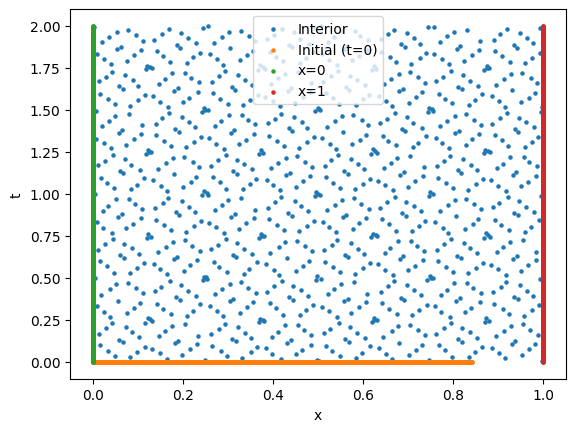

In [14]:
dummy_data = []

for d in train_dataloader:
    dummy_data.append(d)
    
data = torch.cat(dummy_data, dim = 0)

interior = get_interior(data)
ic = get_initial(data, f)
bc_0, bc_L, u_0, u_L = get_BC(data, g)

plt.figure()
plt.scatter(interior[:,0], interior[:,1], s=5, label="Interior")
plt.scatter(ic[:,0], ic[:,1], s=5, label="Initial (t=0)")

plt.scatter(bc_0[:,0], bc_0[:,1], s=5, label="x=0")
plt.scatter(bc_L[:,0], bc_L[:,1], s=5, label="x=1")

plt.legend()
plt.xlabel("x")
plt.ylabel("t")
plt.show()

In [15]:
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 4, neurons = 20)

def get_interior_residual(u_model, points, alpha, epsilon):
    points.requires_grad = True

    u = u_model(points)

    grad_u = torch.autograd.grad(u.sum(), points, create_graph = True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]
    u_xx = torch.autograd.grad(u_x.sum(), points, create_graph=True)[0][:, 0]

    interior_residual = u_t + (alpha * u_x) - (epsilon * u_xx)

    return interior_residual.unsqueeze(1)

In [16]:
interior_data = get_interior(next(iter(train_dataloader)))
get_interior_residual(u_predictor_model, interior_data, 1, 1).shape

torch.Size([32, 1])

In [19]:
def get_IC_residue(u_model, points, f):

    u_0_data = points.clone().detach().requires_grad_(True) # u at t = 0

    u = u_model(u_0_data) 
    ic_1_residue = u - f(u_0_data[:, 0].unsqueeze(1))

    return ic_1_residue

IC_data = get_initial(next(iter(train_dataloader)), f) # u, u_t (exact at t = 0)
get_IC_residue(u_predictor_model, IC_data, f).shape


torch.Size([32, 1])

In [10]:
def get_BC_residue(u_model, points, g):
    return (u_model(points[0]) - g(points[2].unsqueeze(1))) + (u_model(points[1]) - g(points[3].unsqueeze(1)))


BC_data = get_BC(next(iter(train_dataloader))) 
get_BC_residue(u_predictor_model, BC_data, g).shape

torch.Size([32, 1])

In [11]:
def grad_norm(loss, models):
    if not isinstance(models, list):
        models = [models]

    params = []
    for m in models:
        params += list(m.parameters())

    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        allow_unused=True
    )

    norm = 0.0
    for g in grads:
        if g is not None:
            norm += torch.sum(g**2)
    return torch.sqrt(norm)

In [23]:
def smooth(x, w):
        return np.convolve(x, np.ones(w)/w, mode='valid')

def bounds(tracker, window):
    maxs, mins = [], []
    for i in range(len(tracker) // window):
        segment = tracker[i * window : (i + 1) * window]
        maxs.append(max(segment))
        mins.append(min(segment))
    return maxs, mins

def plot_gradients_and_losses(grad_tracker, residue_tracker, window=25):

    pde_maxs, pde_mins = bounds(grad_tracker["pde"], window)
    ic_maxs,  ic_mins  = bounds(grad_tracker["ic"],  window)
    bc_maxs,  bc_mins  = bounds(grad_tracker["bc"],  window)

    band_x = np.arange(len(pde_maxs)) * window

    pde_loss = [v[0] for v in residue_tracker.values()]
    ic_loss  = [v[1] for v in residue_tracker.values()]
    bc_loss  = [v[2] for v in residue_tracker.values()]

    g_pde = grad_tracker["pde"]
    g_ic  = grad_tracker["ic"]
    g_bc  = grad_tracker["bc"]

    ratio_ic = [p / (ic + 1e-8) for ic, p in zip(g_ic, g_pde)]
    ratio_bc = [p / (bc + 1e-8) for bc, p in zip(g_bc, g_pde)]

    print(f"mean ratio pde/ic (first 20 iters): {sum(ratio_ic[:20])/20:.4f}")
    print(f"mean ratio pde/bc (first 20 iters): {sum(ratio_bc[:20])/20:.4f}")

    plt.figure(figsize=(14, 5))

    # Plot 1: grad
    plt.subplot(1, 3, 1)

    s_x = np.arange(len(smooth(g_pde, window)))
    plt.plot(g_pde, alpha=0.15, linewidth=0.5, color="C0")
    plt.plot(g_ic,  alpha=0.15, linewidth=0.5, color="C1")
    plt.plot(g_bc,  alpha=0.15, linewidth=0.5, color="C2")
    plt.plot(s_x, smooth(g_pde, window), color="C0", linewidth=1.2, label="PDE")
    plt.plot(s_x, smooth(g_ic,  window), color="C1", linewidth=1.2, label="IC")
    plt.plot(s_x, smooth(g_bc,  window), color="C2", linewidth=1.2, label="BC")

    plt.fill_between(band_x, pde_mins, pde_maxs, alpha=0.15, color="C0")
    plt.fill_between(band_x, ic_mins,  ic_maxs,  alpha=0.15, color="C1")
    plt.fill_between(band_x, bc_mins,  bc_maxs,  alpha=0.15, color="C2")

    plt.yscale("log")
    plt.title("Gradient Norms")
    plt.xlabel("Iterations")
    plt.ylabel("Gradient Norm")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()

    # Plot 2: losses
    plt.subplot(1, 3, 2)
    plt.plot(pde_loss, label="PDE loss")
    plt.plot(ic_loss,  label="IC loss")
    plt.plot(bc_loss,  label="BC loss")
    plt.yscale("log")   # FIX: log scale so smaller losses are visible
    plt.title("Epochs vs Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()

    # Plot 3: ratios
    plt.subplot(1, 3, 3)
    s_x = np.arange(len(smooth(ratio_ic, window)))
    plt.plot(ratio_ic, alpha=0.15, linewidth=0.5, color="C1")
    plt.plot(ratio_bc, alpha=0.15, linewidth=0.5, color="C2")
    plt.plot(s_x, smooth(ratio_ic, window), color="C1", linewidth=1.2, label="PDE/IC")  # FIX: label matches corrected ratio
    plt.plot(s_x, smooth(ratio_bc, window), color="C2", linewidth=1.2, label="PDE/BC")
    plt.axhline(1.0, linestyle="--", color="black", linewidth=1.0)
    plt.yscale("log")
    plt.title("Gradient Ratios  (1.0 = balanced)")
    plt.xlabel("Iterations")
    plt.ylabel("g_pde / g_other")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [22]:
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 4, neurons = 20)

optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()),
    lr=1e-4
)

alpha = 0.1
epsilon = 10

epoch_loss_track = []
epoch_loss_track_test = []
residue_tracker = {}
grad_tracker = {
    "pde": [],
    "ic": [],
    "bc": []
}

lambda_tracker = {"pde": [], "ic": [], "bc": []}

for epoch in range(EPOCHS):
    lambda_pde = 1.0
    lambda_ic  = 1.0
    lambda_bc  = 1.0
    
    residue_tracker[epoch] = []
    
    epoch_loss = 0
    epoch_loss_test = 0

    epoch_loss_PDE = 0
    epoch_loss_IC = 0
    epoch_loss_BC = 0

    g_pde_epoch = 0
    g_ic_epoch = 0
    g_bc_epoch = 0


    g_pdes = []
    g_ics = []
    g_bcs = []

    for train_data in train_dataloader:
        u_predictor_model.train()


        optimizer.zero_grad()
        interior_data = get_interior(train_data) 
        IC_data       = get_initial(train_data, f) 
        BC_data       = get_BC(train_data, g)


        interior_residue  = get_interior_residual(u_predictor_model, interior_data, alpha, epsilon)
        IC_residue        = get_IC_residue(u_predictor_model, IC_data, f)
        BC_residue        = get_BC_residue(u_predictor_model, BC_data, g)

        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

        models = [u_predictor_model]
        g_pde = grad_norm(loss_pde, models)
        g_ic  = grad_norm(loss_ic, models)
        g_bc  = grad_norm(loss_bc, models)

        g_pdes.append(g_pde)
        g_ics.append(g_ic)
        g_bcs.append(g_bc)

        g_pde_epoch += g_pde
        g_ic_epoch  += g_ic
        g_bc_epoch  += g_bc


        # total of iniduvidual residue
        epoch_loss_PDE += loss_pde
        epoch_loss_IC += loss_ic
        epoch_loss_BC += loss_bc

        # total
        loss = lambda_pde * loss_pde + lambda_ic * loss_ic + lambda_bc * loss_bc
        epoch_loss += loss
        loss.backward()
        optimizer.step()

        grad_tracker["pde"].append(g_pde.item())
        grad_tracker["ic"].append(g_ic.item())
        grad_tracker["bc"].append(g_bc.item())

    g_pde_mean = np.mean([g.item() for g in g_pdes])
    g_ic_mean  = np.mean([g.item() for g in g_ics])
    g_bc_mean  = np.mean([g.item() for g in g_bcs])
    g_max_mean = max(g_pde_mean, g_ic_mean, g_bc_mean)

    beta = 0.9
    # lambda_pde = beta * lambda_pde + (1 - beta) * (g_max_mean / (g_pde_mean + 1e-8))
    lambda_ic  = beta * lambda_ic  + (1 - beta) * (g_max_mean / (g_ic_mean  + 1e-8))
    lambda_bc  = beta * lambda_bc  + (1 - beta) * (g_max_mean / (g_bc_mean  + 1e-8))

    lambda_pde = float(np.clip(lambda_pde, 0.05, 100.0))
    lambda_ic  = float(np.clip(lambda_ic,  0.05, 100.0))
    lambda_bc  = float(np.clip(lambda_bc,  0.05, 100.0))

    lambda_tracker["pde"].append(lambda_pde)
    lambda_tracker["ic"].append(lambda_ic)
    lambda_tracker["bc"].append(lambda_bc)

    residue_tracker[epoch].extend((epoch_loss_PDE.item()/len(train_dataloader), 
                                   epoch_loss_IC.item()/len(train_dataloader), 
                                   epoch_loss_BC.item()/len(train_dataloader)))

    for test_data in test_dataloader:
        
        u_predictor_model.eval()

        interior_data = get_interior(test_data) 
        IC_data       = get_initial(test_data, f) 
        BC_data       = get_BC(test_data, g)

        interior_residue = get_interior_residual(u_predictor_model, interior_data, alpha, epsilon)
        IC_residue       = get_IC_residue(u_predictor_model, IC_data, f)
        BC_residue       = get_BC_residue(u_predictor_model, BC_data, g)

        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

        # total
        loss = loss_pde + loss_ic + loss_bc
        epoch_loss_test += loss
    
    epoch_loss = epoch_loss / len(train_dataloader)
    epoch_loss_track.append(epoch_loss.item())

    epoch_loss_test = epoch_loss_test / len(test_dataloader)
    epoch_loss_track_test.append(epoch_loss_test.item())


    if epoch % 10 == 0:
        print(f"EPOCH: {epoch} | train loss: {epoch_loss.item():.4f} | test loss: {epoch_loss_test.item():.4f}")

EPOCH: 0 | train loss: 2.2689 | test loss: 2.1572
EPOCH: 10 | train loss: 0.3396 | test loss: 0.2504
EPOCH: 20 | train loss: 0.2488 | test loss: 0.2639
EPOCH: 30 | train loss: 0.2247 | test loss: 0.2281
EPOCH: 40 | train loss: 0.1977 | test loss: 0.1610


In [26]:
lambda_tracker['pde'][-1], lambda_tracker['ic'][-1], lambda_tracker['bc'][-1]

(1.0, 1.0124248796328341, 0.9999999993783549)

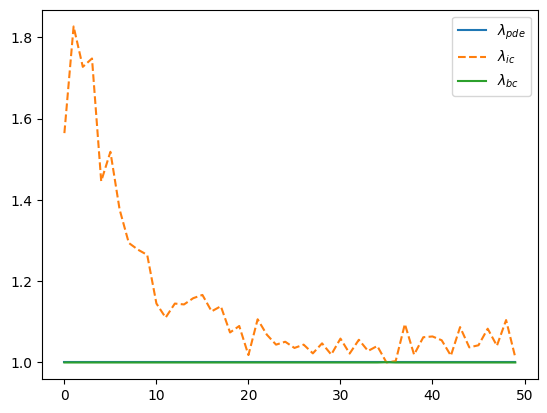

In [25]:
plt.plot(lambda_tracker['pde'], label = "$\lambda_{pde}$")
plt.plot(lambda_tracker['ic'], label = "$\lambda_{ic}$", linestyle = "--")
plt.plot(lambda_tracker['bc'], label = "$\lambda_{bc}$")
plt.legend()

mean ratio pde/ic (first 20 iters): 0.4130
mean ratio pde/bc (first 20 iters): 0.0642


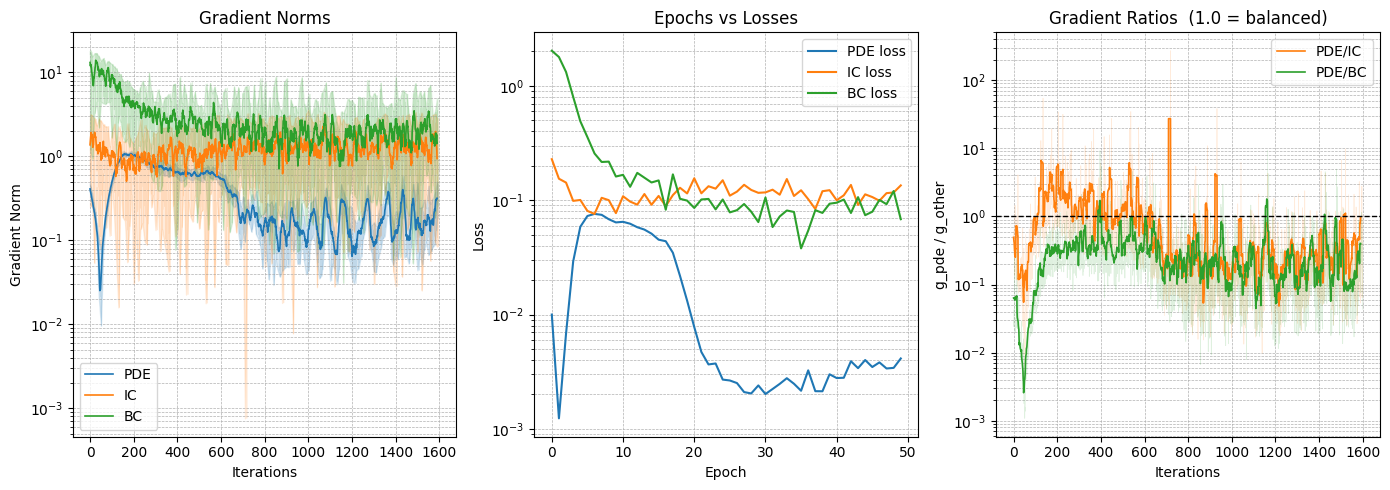

In [24]:
plot_gradients_and_losses(grad_tracker, residue_tracker, window=10)

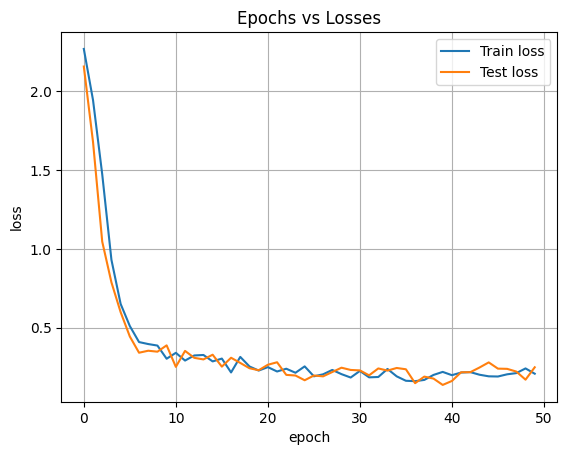

In [28]:
plt.plot(epoch_loss_track, label = "Train loss")
plt.plot(epoch_loss_track_test, label = "Test loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

plt.show()

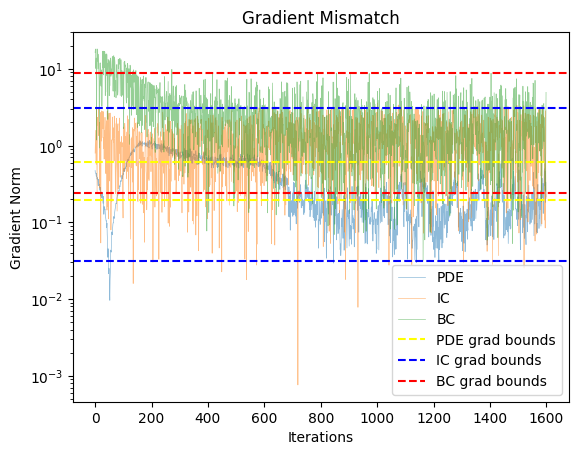

In [27]:
plt.plot(grad_tracker["pde"], label="PDE", alpha = 0.5, linewidth=0.5)
plt.plot(grad_tracker["ic"], label="IC", alpha = 0.5, linewidth=0.5)
plt.plot(grad_tracker["bc"], label="BC", alpha = 0.5, linewidth=0.5)

def bounds(tracker, window):
    pde_maxs = []
    pde_mins = []
    for i in range(len(tracker) // window):
        pde_maxs.append(max(tracker[i * window + i: (i + 1) * window]))
        pde_mins.append(min(tracker[i * window + i: (i + 1) * window]))
    return pde_maxs, pde_mins

pde_maxs, pde_mins = bounds(grad_tracker["pde"], 100)
ic_maxs, ic_mins = bounds(grad_tracker["ic"], 100)
bc_maxs, bc_mins = bounds(grad_tracker["bc"], 100)

pde_avg_max = sum(pde_maxs)/len(pde_maxs)
pde_avg_min = sum(pde_mins)/len(pde_mins)

ic_avg_max = sum(ic_maxs)/len(ic_maxs)
ic_avg_min = sum(ic_mins)/len(ic_mins)

bc_avg_max = sum(bc_maxs)/len(bc_maxs)
bc_avg_min = sum(bc_mins)/len(bc_mins)


plt.axhline(pde_avg_max, linestyle = "--", color = "yellow", label = "PDE grad bounds")
plt.axhline(pde_avg_min, linestyle = "--", color = "yellow")

plt.axhline(ic_avg_max, linestyle = "--", color = "blue", label = "IC grad bounds")
plt.axhline(ic_avg_min, linestyle = "--", color = "blue")

plt.axhline(bc_avg_max, linestyle = "--", color = "red", label = "BC grad bounds")
plt.axhline(bc_avg_min, linestyle = "--", color = "red")

plt.yscale("log")
plt.legend()
plt.title("Gradient Mismatch")
plt.xlabel("Iterations")
plt.ylabel("Gradient Norm")
plt.show()

In [77]:
print(pde_avg_max, ic_avg_max, ic_avg_max)

1.589924193918705 3.415293276309967 3.415293276309967


In [78]:
print(pde_avg_min, ic_avg_min, ic_avg_min)

0.07384188499418087 0.04963485604093876 0.04963485604093876


In [121]:
def inference(domain, u_model, f, g, alpha, epsilon):
    
    domain = domain.clone()
    x_s = torch.linspace(domain[0][0], domain[0][1], 100).requires_grad_(True)
    t_s = torch.linspace(domain[1][0], domain[1][1], 100)

    X, T = torch.meshgrid(x_s, t_s, indexing='ij')

    points = torch.stack((X.flatten(), T.flatten()), dim=1)
    points = points.requires_grad_(True)

    u = u_model(points)
    U = u.reshape(100, 100)

    grad_u = torch.autograd.grad(u.sum(), points, create_graph=True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]

    # interior loss
    u_xx = torch.autograd.grad(u_x.sum(), points, create_graph=True)[0][:, 0]
    loss_pde = torch.mean((u_t + (alpha * u_x) - (epsilon * u_xx))**2)

    # ic loss
    ic_loss = torch.mean((U[:, 0] - f(x_s))**2)

    # bc loss
    bc_loss = torch.mean(((u[:, 0] - g(points[:, 1]))**2) + ((u[:, -1] - g(points[:, 1]))**2))

    U = u.reshape(100, 100)


    fig, ax = plt.subplots(1, 1, figsize=(7, 6))

    im = ax.contourf(X.detach().numpy(), T.detach().numpy(), U.detach().numpy())
    fig.colorbar(im, ax=ax)

    
    rect = patches.Rectangle(
        (0,0),   
        1,
        2,
        linewidth=2,
        edgecolor='r',
        facecolor='none'
    )

    ax.add_patch(rect)

    ax.set_title(f"u(x,t) | interior loss: {loss_pde.item():.4f} | ic loss: {ic_loss.item():.4f} | bc loss: {bc_loss.item():.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    plt.show()

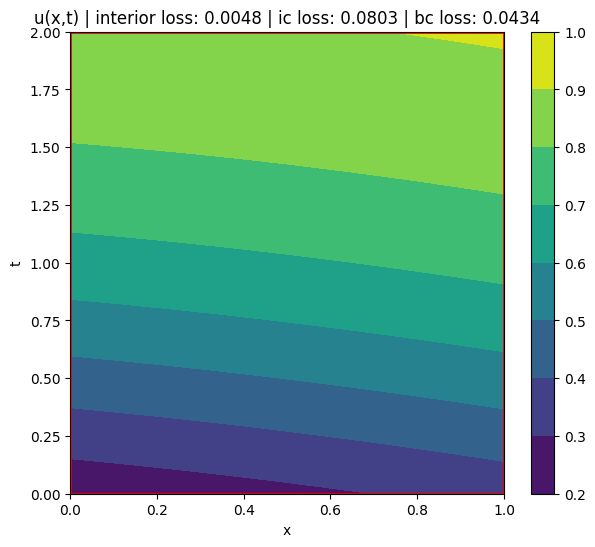

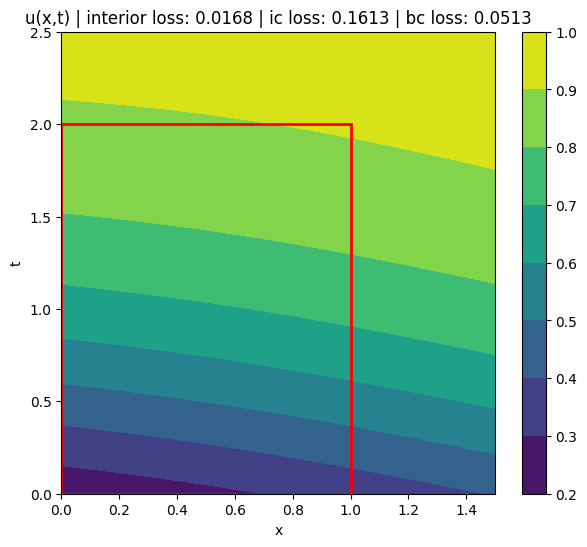

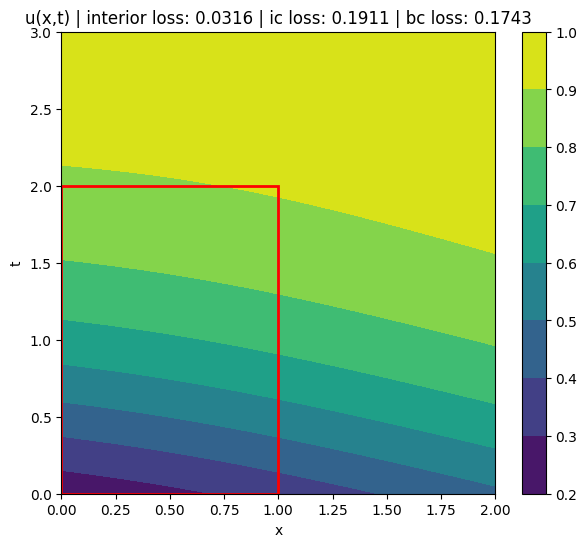

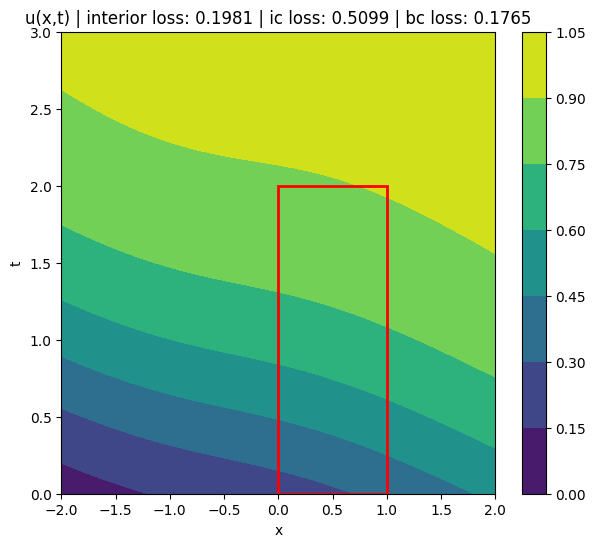

In [123]:
inference(domain = domain, 
          u_model = u_predictor_model, 
          f = f, g = g, 
          alpha = alpha, 
          epsilon = epsilon)

inference(domain = torch.tensor([[0, 1.5], [0, 2.5]]), 
          u_model = u_predictor_model, 
          f = f, g = g, 
          alpha = alpha, 
          epsilon = epsilon)

inference(domain = torch.tensor([[0, 2], [0, 3]]), 
          u_model = u_predictor_model, 
          f = f, g = g, 
          alpha = alpha, 
          epsilon = epsilon)

inference(domain = torch.tensor([[-2, 2], [0, 3]]), 
          u_model = u_predictor_model, 
          f = f, g = g, 
          alpha = alpha, 
          epsilon = epsilon)

In [ ]:
a = torch.tensor([[0,1,5], [2,3,5], [4,5,5]])
a

tensor([[0, 1, 5],
        [2, 3, 5],
        [4, 5, 5]])

In [77]:
t_s

tensor([0.0000, 0.0202, 0.0404, 0.0606, 0.0808, 0.1010, 0.1212, 0.1414, 0.1616,
        0.1818, 0.2020, 0.2222, 0.2424, 0.2626, 0.2828, 0.3030, 0.3232, 0.3434,
        0.3636, 0.3838, 0.4040, 0.4242, 0.4444, 0.4646, 0.4848, 0.5051, 0.5253,
        0.5455, 0.5657, 0.5859, 0.6061, 0.6263, 0.6465, 0.6667, 0.6869, 0.7071,
        0.7273, 0.7475, 0.7677, 0.7879, 0.8081, 0.8283, 0.8485, 0.8687, 0.8889,
        0.9091, 0.9293, 0.9495, 0.9697, 0.9899, 1.0101, 1.0303, 1.0505, 1.0707,
        1.0909, 1.1111, 1.1313, 1.1515, 1.1717, 1.1919, 1.2121, 1.2323, 1.2525,
        1.2727, 1.2929, 1.3131, 1.3333, 1.3535, 1.3737, 1.3939, 1.4141, 1.4343,
        1.4545, 1.4747, 1.4949, 1.5152, 1.5354, 1.5556, 1.5758, 1.5960, 1.6162,
        1.6364, 1.6566, 1.6768, 1.6970, 1.7172, 1.7374, 1.7576, 1.7778, 1.7980,
        1.8182, 1.8384, 1.8586, 1.8788, 1.8990, 1.9192, 1.9394, 1.9596, 1.9798,
        2.0000])